#Imports




In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#Image Augmentation

In [ ]:
from torchvision import datasets
from torch.utils.data.sampler import SubsetRandomSampler

num_workers = 0
batch_size = 20
valid_size = 0.2

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_data = datasets.CIFAR10('data', train=True,
                              download=True, transform=transform_train)
test_data = datasets.CIFAR10('data', train=False,
                             download=True, transform=transform_test)

num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size,
    num_workers=num_workers)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

100%|██████████| 170M/170M [1:05:54<00:00, 43.1kB/s]


#Visualization

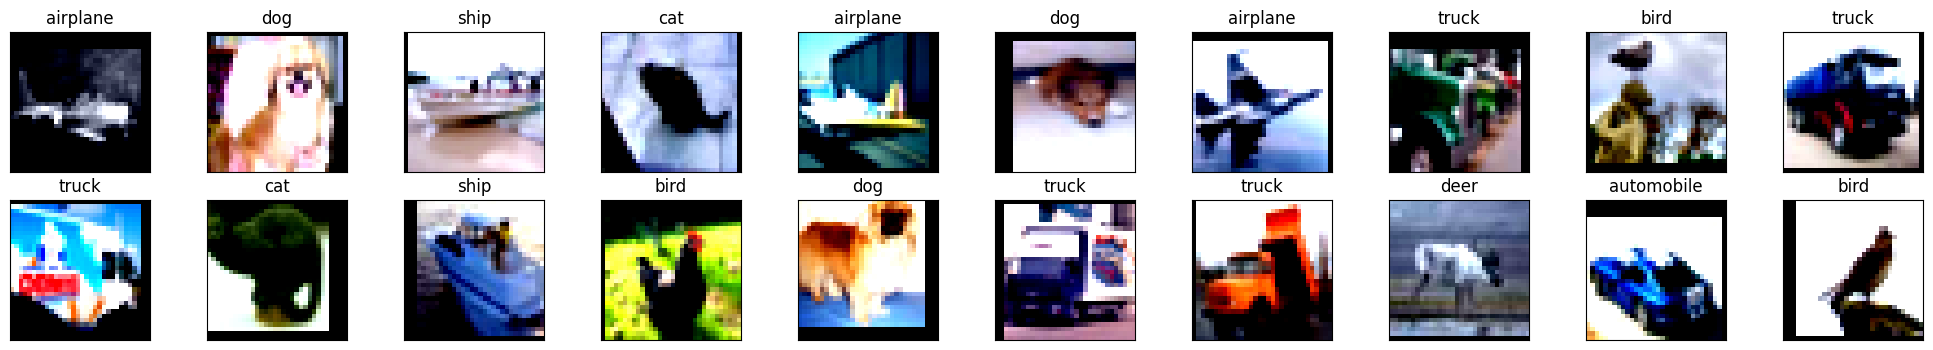

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

def imshow(img):
    img = img / 2 + 0.5
    img = np.clip(img, 0, 1)
    plt.imshow(np.transpose(img, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

fig = plt.figure(figsize=(25, 4))

for idx in np.arange(20):
    ax = fig.add_subplot(2, 20//2, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

#Custom Residual Block

In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)

    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    
    self.downsample = None
    if stride != 1 or in_channels != out_channels:
      self.downsample = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    if self.downsample is not None:
      identity = self.downsample(x)

    out = out + identity  
    out = self.relu(out)
    return out



#Custom ResNet

In [26]:
class CustomResNet(nn.Module):
    def __init__(self, stage_blocks=[2, 2, 2], stage_channels=[64, 128, 256], num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, stage_channels[0], kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(stage_channels[0]),
            nn.ReLU(inplace=True),
        )

        stages = []
        in_channels = stage_channels[0]
        for i, (num_blocks, out_channels) in enumerate(zip(stage_blocks, stage_channels)):
            stride = 1 if i == 0 else 2
            blocks = []
            for b in range(num_blocks):
                s = stride if b == 0 else 1
                blocks.append(ResidualBlock(in_channels, out_channels, stride=s))
                in_channels = out_channels
            stages.append(nn.Sequential(*blocks))
        self.stages = nn.ModuleList(stages)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(stage_channels[-1], num_classes)

    def forward(self, x):
        x = self.stem(x)
        for stage in self.stages:
            x = stage(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

#Training Setup

In [27]:
model = CustomResNet()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

epochs = 40

#Training Loop

In [28]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        if train:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                out = model(xb)
                loss = criterion(out, yb)

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)

    return total_loss / total, correct / total

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(epochs):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(valid_loader, train=False)
    scheduler.step()

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f}")

Epoch 1/40 | train_loss 1.8754 acc 0.2903 | val_loss 1.6330 acc 0.4072
Epoch 2/40 | train_loss 1.4310 acc 0.4789 | val_loss 1.2967 acc 0.5429
Epoch 3/40 | train_loss 1.2100 acc 0.5734 | val_loss 1.0974 acc 0.6134
Epoch 4/40 | train_loss 1.0688 acc 0.6287 | val_loss 1.3388 acc 0.5267
Epoch 5/40 | train_loss 0.9839 acc 0.6606 | val_loss 1.1046 acc 0.6311
Epoch 6/40 | train_loss 0.9376 acc 0.6795 | val_loss 0.9818 acc 0.6709
Epoch 7/40 | train_loss 0.9022 acc 0.6890 | val_loss 1.0115 acc 0.6674
Epoch 8/40 | train_loss 0.8812 acc 0.7001 | val_loss 1.0276 acc 0.6532
Epoch 9/40 | train_loss 0.8553 acc 0.7083 | val_loss 0.9174 acc 0.6863
Epoch 10/40 | train_loss 0.8422 acc 0.7100 | val_loss 0.9560 acc 0.6739
Epoch 11/40 | train_loss 0.8239 acc 0.7191 | val_loss 0.8626 acc 0.7058
Epoch 12/40 | train_loss 0.8090 acc 0.7233 | val_loss 0.7806 acc 0.7326
Epoch 13/40 | train_loss 0.7937 acc 0.7277 | val_loss 0.9765 acc 0.6748
Epoch 14/40 | train_loss 0.7786 acc 0.7365 | val_loss 1.3505 acc 0.5802
E

#Training and Validation curves

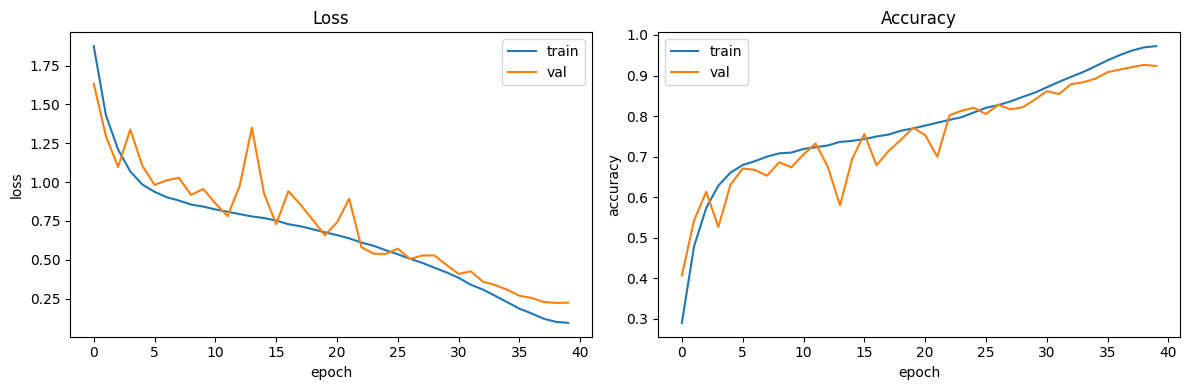

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].set_title("Loss")

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs, label="val")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()
axes[1].set_title("Accuracy")

plt.tight_layout()
plt.show()

#Evaluation Metrics

Final test accuracy: 0.9216

              precision    recall  f1-score   support

    airplane       0.92      0.93      0.92      1000
  automobile       0.95      0.97      0.96      1000
        bird       0.90      0.89      0.89      1000
         cat       0.87      0.82      0.84      1000
        deer       0.91      0.94      0.92      1000
         dog       0.85      0.90      0.87      1000
        frog       0.95      0.94      0.94      1000
       horse       0.97      0.94      0.96      1000
        ship       0.95      0.95      0.95      1000
       truck       0.95      0.95      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



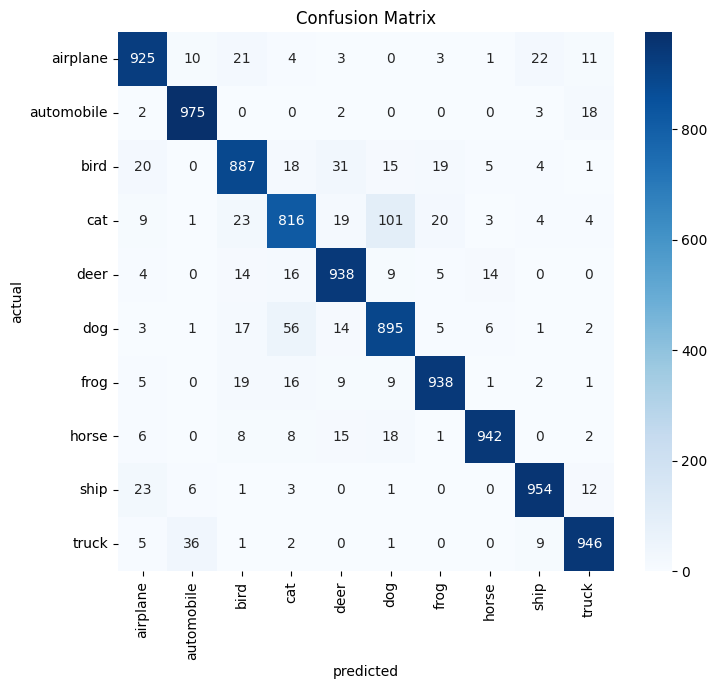

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        preds = out.argmax(1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

print("Final test accuracy:", (all_preds == all_true).mean())
print()
print(classification_report(all_true, all_preds, target_names=classes))

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("Confusion Matrix")
plt.show()

#Saving Model Weights

In [31]:
torch.save(model.state_dict(), "ResNet.pth")
print("saved weights to ResNet.pth")

saved weights to ResNet.pth
